# Part 3: Clean Signal & Frequency Analysis
**Author:** Zoé Sauge

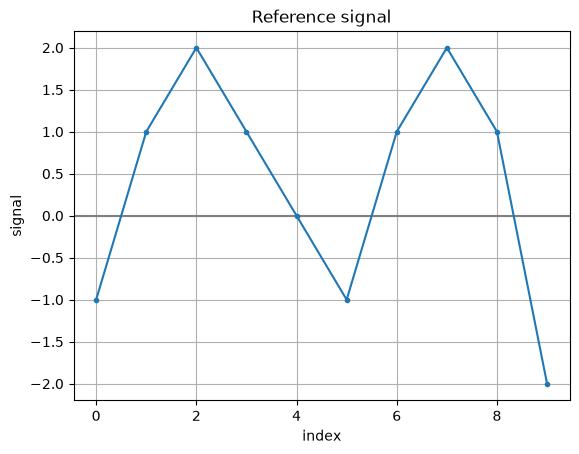

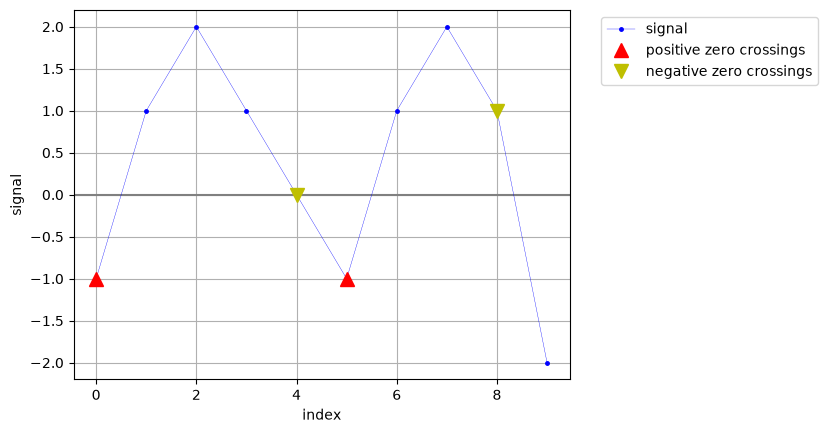

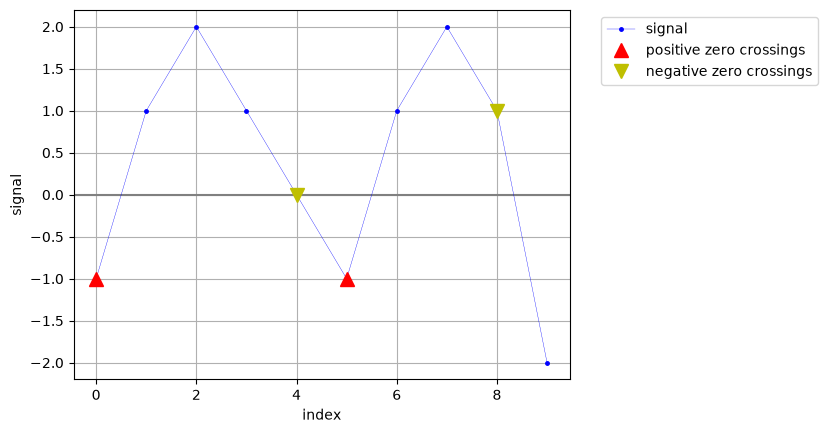

Help on function find_zero_crossings in module __main__:

find_zero_crossings(s: np.ndarray)
    Find the positive and negative zero crossings of a 1D signal.

    Zeros in the signal are handled: a sequence like [1, 0, -1] counts
    as ONE negative crossing.

    Parameters
    ----------
    s : np.ndarray (or list)
        1D signal.

    Returns
    -------
    i_cross_pos : np.ndarray
        Indices of positive zero crossings (signal goes up through 0).
    i_cross_neg : np.ndarray
        Indices of negative zero crossings (signal goes down through 0).
        Each index is the last sample before the sign change.

    Raises
    ------
    ValueError
        If the input is not a 1D array.

All teacher's tests passed.
All additional tests passed.
All local extrema tests passed.


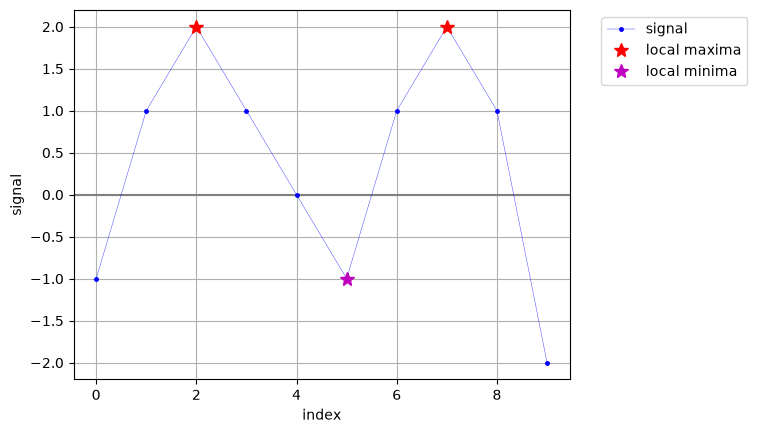

In [40]:
# Import functions from Part 2 created by Sarah
%run part2_functions.ipynb

## 3.1. Create the signal and plot it
We define the sampling frequency (`FS = 100 Hz`) and create the time vector `t` ranging from 0 to 2 seconds. Then, we generate the clean signal `s` as a combination of two sine waves (`s1` and `s2`), matching the reference figures.

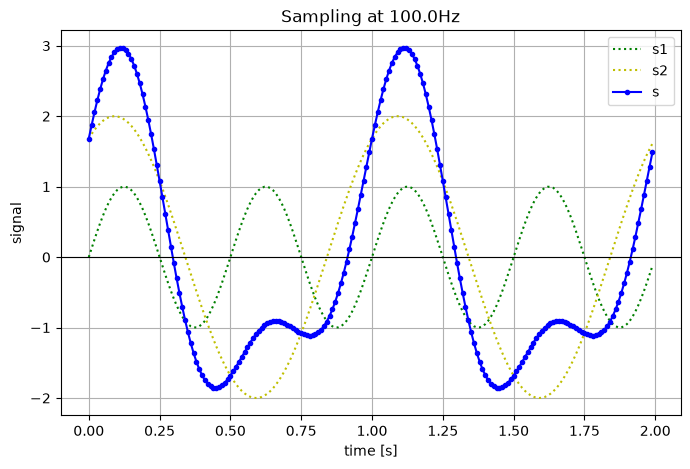

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Define sampling frequency
FS = 100.0
t = np.arange(0, 2, 1 / FS)
s1 = np.sin(2 * np.pi * 2 * t)
s2 = 2 * np.sin(2 * np.pi * 1 * t + 1)
s = s1 + s2

# Plot the signals as shown in instruction 3.1
plt.figure(figsize=(8, 5))
plt.plot(t, s1, 'g:', label='s1')
plt.plot(t, s2, 'y:', label='s2')
plt.plot(t, s, 'b.-', label='s')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('time [s]')
plt.ylabel('signal')
plt.title('Sampling at 100.0Hz')
plt.grid(True)
plt.legend()
plt.show()

## 3.2. Plot the remarkable points
Using the functions defined in Part 2, we identify and plot the local maxima, local minima, and zero crossings.

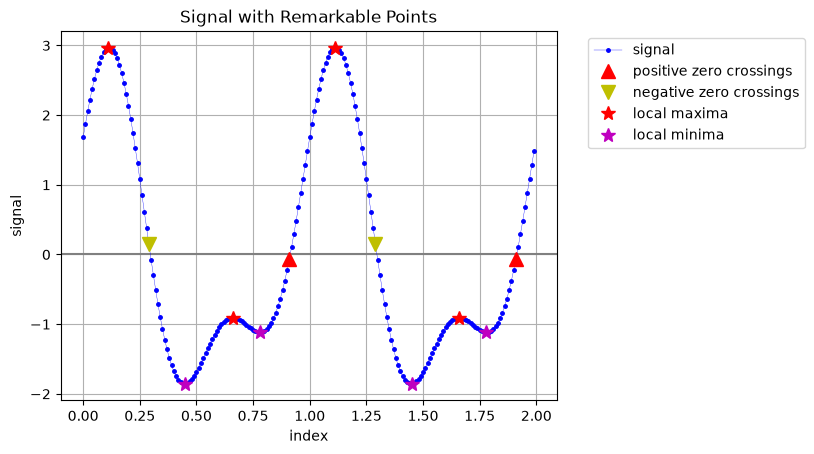

In [42]:
# Call the display function from Part 2 to show the signal and its remarkable points
display_signal_and_remarkable_points(t, s, title="Signal with Remarkable Points")

## 3.3. Use the remarkable points to find the frequency of the signal
We compute the frequency of the signal by analyzing the time intervals (periods) between consecutive zero-crossing points sharing the same slope.

In [43]:
def compute_frequency_from_zero_crossings(t: np.ndarray, s: np.ndarray) -> dict:
    """Compute the period and frequency of a signal from its zero crossings.

    Zero crossings with the same slope are one period apart.

    Parameters
    ----------
    t : np.ndarray
        Time vector (s), regularly sampled.
    s : np.ndarray
        Signal values.

    Returns
    -------
    dict
        Deltas between zero crossings (samples), periods (s) and frequency (Hz).
    """
    fs = 1 / (t[1] - t[0])                       # sampling frequency computed from t
    i_pos, i_neg = find_zero_crossings(s)        # function from part 2

    # Number of samples between consecutive crossings with the same slope
    delta_pos = np.diff(i_pos)
    delta_neg = np.diff(i_neg)

    # Convert samples to seconds
    period_pos = np.mean(delta_pos) / fs
    period_neg = np.mean(delta_neg) / fs
    period = (period_pos + period_neg) / 2

    return {
        "delta_zero_crossing_pos (samples)": delta_pos,
        "delta_zero_crossing_neg (samples)": delta_neg,
        "signal_period_pos (s)": period_pos,
        "signal_period_neg (s)": period_neg,
        "signal_period (s)": period,
        "signal_frequency (Hz)": 1 / period,
    }


def print_frequency_info(info: dict, title: str = ""):
    """Print the frequency information with keys aligned to the right."""
    if title:
        print(title)
    width = max(len(key) for key in info)        # length of the longest key
    for key, value in info.items():
        print(f"  {key:>{width}} : {value}")


frequency_info = compute_frequency_from_zero_crossings(t, s)
print_frequency_info(frequency_info, "Analysis of the clean signal:")


Analysis of the clean signal:
  delta_zero_crossing_pos (samples) : [100]
  delta_zero_crossing_neg (samples) : [100]
              signal_period_pos (s) : 1.0
              signal_period_neg (s) : 1.0
                  signal_period (s) : 1.0
              signal_frequency (Hz) : 1.0
